# Reproducible Crack Segmentation with UNet + QCAB

## Overview

This notebook provides a reproducible implementation of the proposed crack segmentation pipeline based on a UNet backbone and the QCAB module.

To improve transparency and facilitate further research, the workflow is organized around a predefined dataset package with fixed `train`, `val`, and `test` splits in COCO format. All experiments are therefore conducted on the same data partition, ensuring consistent evaluation across runs.

The notebook covers the following stages:

- environment setup and deterministic configuration
- dataset extraction and split discovery
- COCO-based data loading
- model construction and training
- validation and test-time evaluation
- experiment logging and result export

This implementation is intended to support open-source release and reproducible benchmarking.


## Dataset Loading and Fixed Split Initialization

This section initializes the complete data pipeline used in the notebook.

The dataset is loaded from a packaged archive, `custom_split_export.zip`, which contains predefined `train`, `val`, and `test` folders together with their corresponding COCO annotation files. This design avoids runtime re-splitting of the dataset and ensures that all experiments are conducted on the same fixed partition.

Using a predefined split is important for reproducibility and fair comparison. In particular, it helps prevent unintended data leakage between subsets and guarantees that validation and test results remain comparable across different runs, model settings, and ablation studies.

This cell performs the following tasks:

1. imports the required libraries and defines the global experimental configuration;
2. checks optional dependencies and enables deterministic behavior when supported;
3. extracts the packaged dataset archive into a temporary working directory;
4. automatically locates the `train`, `val`, and `test` folders and their annotation files;
5. loads the dataset in COCO format for the target category (`crack`);
6. initializes the fixed split variables used throughout the rest of the notebook;
7. reports basic split statistics as a sanity check before training.

The loaded outputs are stored in the following variables and are reused by downstream cells:

- `FIXED_TRAIN_IMAGES`, `FIXED_VAL_IMAGES`, `FIXED_TEST_IMAGES`: image metadata for each split;
- `FIXED_TRAIN_ANN`, `FIXED_VAL_ANN`, `FIXED_TEST_ANN`: annotations grouped by image;
- `FIXED_TRAIN_DIR`, `FIXED_VAL_DIR`, `FIXED_TEST_DIR`: resolved image directories;
- `category_id`, `categories`: category information derived from the COCO annotations.

By standardizing dataset loading in a single cell, the notebook becomes easier to inspect, reuse, and reproduce in an open-source setting.

In [1]:
# =========================================================
# ONE-CELL LOADER FOR custom_split_export.zip
# Compatible with current flow:
# - FIXED_TRAIN_IMAGES / FIXED_VAL_IMAGES / FIXED_TEST_IMAGES
# - FIXED_TRAIN_ANN / FIXED_VAL_ANN / FIXED_TEST_ANN
# - FIXED_TRAIN_DIR / FIXED_VAL_DIR / FIXED_TEST_DIR
# - category_id, categories
# =========================================================

# -----------------------------
# 1) Imports + global config
# -----------------------------
import os
import cv2
import gc
import sys
import json
import math
import time
import glob
import random
import zipfile
import hashlib
import shutil
import subprocess
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.models import load_model

# ====== CHANGE THIS ONLY IF YOUR ZIP HAS A DIFFERENT NAME ======
ZIP_PATH = "/content/crack_segmentation_dataset_coco.zip"
EXTRACT_DIR = "/content/crack_segmentation_dataset"
OUTPUT_DIR = "/content/qcab_outputs"

TARGET_CLASS = "crack"
KEEP_IMAGES_WITHOUT_CRACK = True

IMG_SIZE = (384, 384)
BATCH_SIZE = 4
NUM_CLASSES = 1

EPOCHS = 10
LEARNING_RATE = 1e-3

TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1
assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-8

GLOBAL_SEED = 42
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("TensorFlow version:", tf.__version__)
print("ZIP_PATH          :", ZIP_PATH)
print("OUTPUT_DIR        :", OUTPUT_DIR)
print("IMG_SIZE          :", IMG_SIZE)
print("BATCH_SIZE        :", BATCH_SIZE)
print("EPOCHS            :", EPOCHS)

# -----------------------------
# 2) Optional dependencies + determinism
# -----------------------------
def ensure_package(package_name, import_name=None):
    import importlib.util
    import_name = import_name or package_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])
    else:
        print(f"{package_name} is already available.")

ensure_package("pycocotools", "pycocotools")
from pycocotools import mask as mask_utils

def set_global_determinism(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

try:
    tf.config.experimental.enable_op_determinism()
    print("TensorFlow deterministic operations are enabled.")
except Exception as e:
    print("Deterministic TensorFlow operations could not be fully enabled:", e)

set_global_determinism(GLOBAL_SEED)

# -----------------------------
# 3) Unzip dataset
# -----------------------------
if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(
        f"ZIP file not found at {ZIP_PATH}. "
        "Please upload custom_split_export.zip to the expected location first."
    )

# Remove the old extraction directory to avoid mixing files from previous runs
if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)
os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    zf.extractall(EXTRACT_DIR)

print(f"Dataset extracted to: {EXTRACT_DIR}")

# -----------------------------
# 4) Print tree + find split files
# -----------------------------
def print_tree(base_dir, max_depth=2, max_files=10):
    for root, dirs, files in os.walk(base_dir):
        depth = root.replace(base_dir, "").count(os.sep)
        if depth > max_depth:
            continue
        indent = "  " * depth
        print(f"{indent}{os.path.basename(root)}/")
        for f in files[:max_files]:
            print(f"{indent}  {f}")

def find_split_dir(base_dir, split_names):
    # Prefer direct subdirectories first
    for name in split_names:
        direct = os.path.join(base_dir, name)
        if os.path.isdir(direct):
            return direct

    # Fallback: recursive search
    for name in split_names:
        matches = glob.glob(os.path.join(base_dir, "**", name), recursive=True)
        for m in matches:
            if os.path.isdir(m):
                return m
    return None

def find_annotation_file(split_dir):
    if split_dir is None:
        return None
    patterns = [
        "_annotations.coco.json",
        "annotations.coco.json",
        "_annotations.json",
        "annotations.json",
    ]
    for p in patterns:
        candidate = os.path.join(split_dir, p)
        if os.path.exists(candidate):
            return candidate
    jsons = glob.glob(os.path.join(split_dir, "*.json"))
    return jsons[0] if jsons else None

print_tree(EXTRACT_DIR, max_depth=2, max_files=10)

RAW_TRAIN_DIR = find_split_dir(EXTRACT_DIR, ["train", "TRAIN"])
RAW_VAL_DIR   = find_split_dir(EXTRACT_DIR, ["val", "valid", "VAL", "VALID"])
RAW_TEST_DIR  = find_split_dir(EXTRACT_DIR, ["test", "TEST"])

RAW_TRAIN_ANN = find_annotation_file(RAW_TRAIN_DIR)
RAW_VAL_ANN   = find_annotation_file(RAW_VAL_DIR)
RAW_TEST_ANN  = find_annotation_file(RAW_TEST_DIR)

print("RAW_TRAIN_DIR:", RAW_TRAIN_DIR)
print("RAW_VAL_DIR  :", RAW_VAL_DIR)
print("RAW_TEST_DIR :", RAW_TEST_DIR)
print("RAW_TRAIN_ANN:", RAW_TRAIN_ANN)
print("RAW_VAL_ANN  :", RAW_VAL_ANN)
print("RAW_TEST_ANN :", RAW_TEST_ANN)

# Strict validation to prevent downstream errors
if RAW_TRAIN_DIR is None or RAW_TRAIN_ANN is None:
    raise ValueError("A valid train split could not be found in custom_split_export.zip.")
if RAW_VAL_DIR is None or RAW_VAL_ANN is None:
    raise ValueError("A valid validation split could not be found in custom_split_export.zip.")
if RAW_TEST_DIR is None or RAW_TEST_ANN is None:
    raise ValueError("A valid test split could not be found in custom_split_export.zip.")

# -----------------------------
# 5) COCO load helper
# -----------------------------
def load_coco_data(
    data_dir,
    annotation_file,
    target_category_name="crack",
    keep_images_without_target=True
):
    if data_dir is None:
        raise ValueError("data_dir is None.")
    if annotation_file is None:
        raise ValueError("annotation_file is None.")
    if not os.path.exists(annotation_file):
        raise FileNotFoundError(f"Annotation file not found: {annotation_file}")

    with open(annotation_file, "r", encoding="utf-8") as f:
        coco = json.load(f)

    images = coco.get("images", [])
    annotations = coco.get("annotations", [])
    categories = coco.get("categories", [])
    if not categories:
        raise ValueError("No categories were found in the COCO annotation file.")

    name_to_id = {c["name"]: c["id"] for c in categories}
    print("Categories in", os.path.basename(annotation_file))
    for c in categories:
        print(f"  id={c['id']} | name={c['name']}")

    if target_category_name not in name_to_id:
        raise ValueError(
            f"Category '{target_category_name}' was not found. "
            f"Available categories: {list(name_to_id.keys())}"
        )

    target_category_id = name_to_id[target_category_name]
    annotations_by_image = defaultdict(list)
    image_ids_with_target = set()

    for ann in annotations:
        if ann.get("category_id") == target_category_id:
            annotations_by_image[ann["image_id"]].append(ann)
            image_ids_with_target.add(ann["image_id"])

    images_info = []
    for img in images:
        candidate = os.path.join(data_dir, img["file_name"])
        if not os.path.exists(candidate):
            candidate = os.path.join(data_dir, os.path.basename(img["file_name"]))
            if os.path.exists(candidate):
                img = dict(img)
                img["file_name"] = os.path.basename(img["file_name"])
        if not os.path.exists(candidate):
            continue

        has_target = img["id"] in image_ids_with_target
        if keep_images_without_target or has_target:
            images_info.append(img)

    print(f"Loaded images      : {len(images_info)}")
    print(f"Images with target : {len(image_ids_with_target)}")
    print(f"Target category id : {target_category_id} ({target_category_name})")
    return images_info, annotations_by_image, target_category_id, categories

# -----------------------------
# 6) Load fixed split directly from zip
# -----------------------------
print("Using the predefined train/val/test split from custom_split_export.zip.")

FIXED_TRAIN_IMAGES, FIXED_TRAIN_ANN, category_id, categories = load_coco_data(
    RAW_TRAIN_DIR, RAW_TRAIN_ANN, TARGET_CLASS, KEEP_IMAGES_WITHOUT_CRACK
)
FIXED_VAL_IMAGES, FIXED_VAL_ANN, _, _ = load_coco_data(
    RAW_VAL_DIR, RAW_VAL_ANN, TARGET_CLASS, KEEP_IMAGES_WITHOUT_CRACK
)
FIXED_TEST_IMAGES, FIXED_TEST_ANN, _, _ = load_coco_data(
    RAW_TEST_DIR, RAW_TEST_ANN, TARGET_CLASS, KEEP_IMAGES_WITHOUT_CRACK
)

FIXED_TRAIN_DIR = RAW_TRAIN_DIR
FIXED_VAL_DIR = RAW_VAL_DIR
FIXED_TEST_DIR = RAW_TEST_DIR

print("\n===== FIXED SPLIT =====")
print("Train images      :", len(FIXED_TRAIN_IMAGES))
print("Validation images :", len(FIXED_VAL_IMAGES))
print("Test images       :", len(FIXED_TEST_IMAGES))
print("Target category id:", category_id)

# -----------------------------
# 7) Fixed split statistics
# -----------------------------
def count_positive_images(images_info, annotations_by_image):
    pos = 0
    for img in images_info:
        if len(annotations_by_image.get(img["id"], [])) > 0:
            pos += 1
    return pos

for split_name, imgs, anns in [
    ("train", FIXED_TRAIN_IMAGES, FIXED_TRAIN_ANN),
    ("val", FIXED_VAL_IMAGES, FIXED_VAL_ANN),
    ("test", FIXED_TEST_IMAGES, FIXED_TEST_ANN),
]:
    pos = count_positive_images(imgs, anns)
    print(f"{split_name:>5} | total={len(imgs):4d} | positive={pos:4d} | negative={len(imgs)-pos:4d}")

TensorFlow version: 2.19.0
ZIP_PATH          : /content/crack_segmentation_dataset_coco.zip
OUTPUT_DIR        : /content/qcab_outputs
IMG_SIZE          : (384, 384)
BATCH_SIZE        : 4
EPOCHS            : 10
pycocotools is already available.
TensorFlow deterministic operations are enabled.
Dataset extracted to: /content/crack_segmentation_dataset
crack_segmentation_dataset/
  train/
    12484_1_jpg.rf.0WgONGMKqF9qe2npQWDv.jpg
    00984_jpg.rf.4IxU9Pk8SS4V2ah8YjYP.jpg
    17276_1_jpg.rf.Jrctl19sav2LXjXmbSw0.jpg
    12412_1_jpg.rf.iUsl6mI78A8Dx35yJ9DP.jpg
    15726_1_jpg.rf.ayZbM5ajDZc32UOFIhAk.jpg
    03662_jpg.rf.JJji1dJQX6or9zRVpVbV.jpg
    08835_jpg.rf.ZsLNeYVZpwlTjFVLG4jt.jpg
    13591_1_jpg.rf.mCXMqpaoplLtVssigDIV.jpg
    10671_1_jpg.rf.j2cPn3weS8ZS73qS3iN4.jpg
    10916_1_jpg.rf.Fs9wlz3dD6COUhN5M2s1.jpg
  val/
    16870_1_jpg.rf.udkDkYmbBSQg6a7x5JA6.jpg
    16084_1_jpg.rf.fokC0lO6Mnz2Rard3pzR.jpg
    03238_jpg.rf.PBpBnnNiScFpxp9zZyVz.jpg
    03427_jpg.rf.26jhmXyGSdZF0a31Kmat.jpg

## 8. Deterministic COCO Data Generator

This section defines the data generator used to feed images and segmentation masks into the model during training and evaluation.

The generator is designed to work directly with the fixed COCO-based dataset split initialized earlier. For each sample, it loads the input image, reconstructs the crack mask from the corresponding COCO annotations, resizes both image and mask to the target resolution, and returns them in batch form.

To support reproducibility, the generator uses deterministic indexing and controlled shuffling based on a fixed random seed. This helps ensure that repeated runs operate on the same data partition under the same loading logic, which is important for stable comparison across experiments.

The generator supports multiple annotation formats commonly encountered in COCO datasets, including polygon-based segmentation, run-length encoding (RLE), and bounding-box fallback masks when needed.

In [ ]:
# =========================================================
# 8) Deterministic COCO generator
# =========================================================
class CrackCocoDataGenerator(tf.keras.utils.Sequence):
    def __init__(
        self,
        images_info,
        annotations_by_image,
        category_id,
        data_dir,
        batch_size=4,
        img_size=(384, 384),
        shuffle=True,
        seed=42
    ):
        super().__init__()
        self.images_info = list(images_info)
        self.annotations_by_image = annotations_by_image
        self.category_id = category_id
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.rng = np.random.default_rng(seed)
        self.indexes = np.arange(len(self.images_info))
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.images_info) / self.batch_size)

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.images_info))
        if self.shuffle:
            self.indexes = self.rng.permutation(self.indexes)

    def __getitem__(self, index):
        batch_ids = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        batch_images = [self.images_info[i] for i in batch_ids]

        x_list, y_list = [], []
        for img_info in batch_images:
            image = self._load_image(img_info)
            mask = self._build_mask(img_info)

            image = cv2.resize(image, (self.img_size[1], self.img_size[0]), interpolation=cv2.INTER_LINEAR)
            mask = cv2.resize(mask, (self.img_size[1], self.img_size[0]), interpolation=cv2.INTER_NEAREST)

            image = image.astype(np.float32) / 255.0
            mask = mask.astype(np.float32)[..., None]

            x_list.append(image)
            y_list.append(mask)

        return np.stack(x_list, axis=0), np.stack(y_list, axis=0)

    def _resolve_image_path(self, file_name):
        candidate = os.path.join(self.data_dir, file_name)
        if os.path.exists(candidate):
            return candidate
        candidate = os.path.join(self.data_dir, os.path.basename(file_name))
        if os.path.exists(candidate):
            return candidate
        raise FileNotFoundError(f"Không tìm thấy ảnh: {file_name}")

    def _load_image(self, img_info):
        img_path = self._resolve_image_path(img_info["file_name"])
        image = cv2.imread(img_path)
        if image is None:
            raise ValueError(f"Không đọc được ảnh: {img_path}")
        return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    def _build_mask(self, img_info):
        h = img_info["height"]
        w = img_info["width"]
        mask = np.zeros((h, w), dtype=np.uint8)
        anns = self.annotations_by_image.get(img_info["id"], [])

        for ann in anns:
            seg = ann.get("segmentation", None)

            if isinstance(seg, list) and len(seg) > 0:
                for poly in seg:
                    if not isinstance(poly, list) or len(poly) < 6:
                        continue
                    pts = np.array(poly, dtype=np.float32).reshape(-1, 2)
                    pts = np.round(pts).astype(np.int32)
                    cv2.fillPoly(mask, [pts], 1)

            elif isinstance(seg, dict):
                try:
                    rle = mask_utils.frPyObjects(seg, h, w) if isinstance(seg.get("counts"), list) else seg
                    decoded = mask_utils.decode(rle)
                    if decoded.ndim == 3:
                        decoded = np.max(decoded, axis=2)
                    mask = np.maximum(mask, decoded.astype(np.uint8))
                except Exception:
                    pass

            elif "bbox" in ann:
                x, y, bw, bh = ann["bbox"]
                x1 = max(0, int(round(x)))
                y1 = max(0, int(round(y)))
                x2 = min(w, int(round(x + bw)))
                y2 = min(h, int(round(y + bh)))
                mask[y1:y2, x1:x2] = 1

        return mask


## 9. Generator Initialization and Sanity Check

This section defines a small factory function for creating fresh training, validation, and test generators from the fixed dataset split.

Reinitializing the generators through a dedicated factory helps keep the data pipeline consistent across repeated experiments while avoiding unintended state carryover between runs. This is particularly useful when conducting multiple training sessions, ablation studies, or evaluation runs within the same notebook.

A lightweight smoke test is also performed to confirm that the generated batches have the expected tensor shapes, data types, and value ranges before the training stage begins.

In [ ]:
# =========================================================
# 9) Fresh generators factory + smoke test
# =========================================================
def make_generators(seed=42, batch_size=BATCH_SIZE, img_size=IMG_SIZE):
    train_gen = CrackCocoDataGenerator(
        FIXED_TRAIN_IMAGES, FIXED_TRAIN_ANN, category_id, FIXED_TRAIN_DIR,
        batch_size=batch_size, img_size=img_size, shuffle=True, seed=seed
    )
    val_gen = CrackCocoDataGenerator(
        FIXED_VAL_IMAGES, FIXED_VAL_ANN, category_id, FIXED_VAL_DIR,
        batch_size=batch_size, img_size=img_size, shuffle=False, seed=seed
    )
    test_gen = CrackCocoDataGenerator(
        FIXED_TEST_IMAGES, FIXED_TEST_ANN, category_id, FIXED_TEST_DIR,
        batch_size=batch_size, img_size=img_size, shuffle=False, seed=seed
    )
    return train_gen, val_gen, test_gen

train_gen_smoke, val_gen_smoke, test_gen_smoke = make_generators(seed=GLOBAL_SEED)
xb, yb = train_gen_smoke[0]
print("x_batch:", xb.shape, xb.dtype, xb.min(), xb.max())
print("y_batch:", yb.shape, yb.dtype, np.unique(yb))


x_batch: (4, 384, 384, 3) float32 0.08627451 1.0
y_batch: (4, 384, 384, 1) float32 [0. 1.]


## 10. Visual Inspection of Input Samples and Masks

This section provides a qualitative sanity check of the loaded training data by visualizing example image–mask pairs from the generator output.

Inspecting a small batch before training is a useful validation step, as it helps confirm that the image loading, mask reconstruction, resizing, and normalization stages are all functioning as expected. It also makes it easier to detect annotation misalignment, corrupted samples, or preprocessing errors early in the workflow.

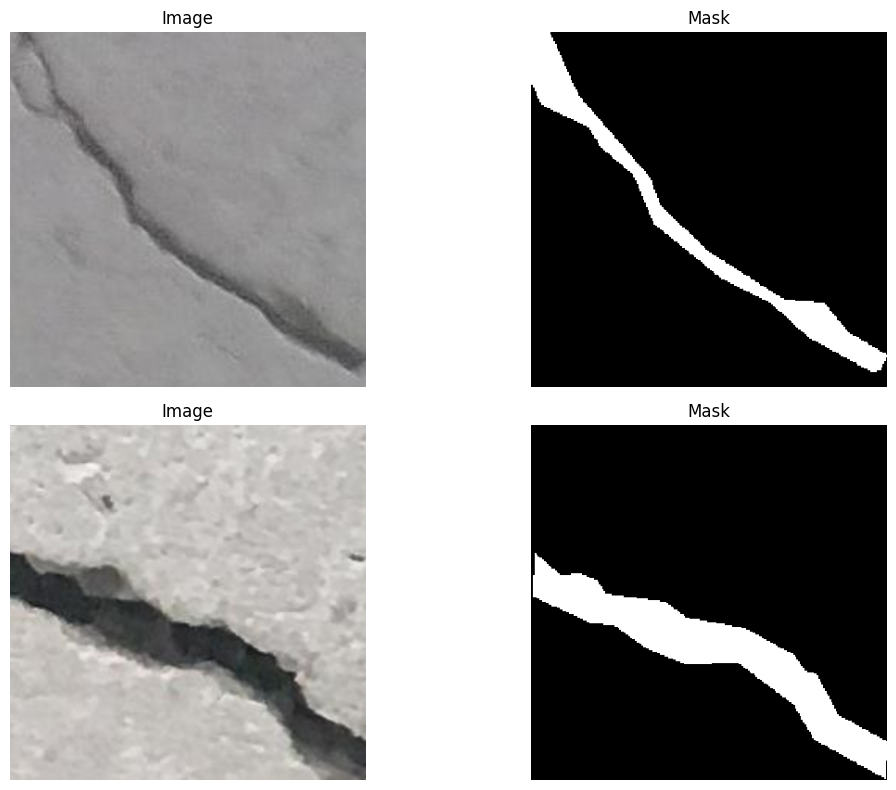

In [ ]:
# =========================================================
# 10) Visual sanity-check
# =========================================================
def show_batch_samples(generator, n=2):
    x_batch, y_batch = generator[0]
    n = min(n, len(x_batch))
    plt.figure(figsize=(12, 4*n))
    for i in range(n):
        plt.subplot(n, 2, 2*i + 1)
        plt.imshow(x_batch[i])
        plt.title("Image")
        plt.axis("off")

        plt.subplot(n, 2, 2*i + 2)
        plt.imshow(y_batch[i].squeeze(), cmap="gray")
        plt.title("Mask")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch_samples(train_gen_smoke, n=2)


## 11. Core Architectural Building Blocks

This section defines the main building blocks used to construct the segmentation network.

It includes a standard convolutional feature extraction block, a squeeze-and-excitation (SE) channel recalibration block, and the proposed **Quantum Channel Attention Bottleneck (QCAB)** module. These components form the foundation of the model architecture developed in this notebook.

The QCAB module is designed to enhance channel-wise feature modulation by combining global feature descriptors with a parameterized attention transformation. In the present implementation, the module supports pooled summary features, compact latent projections, optional trigonometric feature mixing, dropout regularization, and residual channel scaling.

Defining these components separately improves readability, supports modular experimentation, and makes the implementation easier to inspect and reuse in an open-source setting.

In [ ]:
# =========================================================
# 11) Core blocks
# =========================================================
def conv_block(x, filters, name_prefix="conv"):
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False, name=f"{name_prefix}_1")(x)
    x = layers.BatchNormalization(name=f"{name_prefix}_bn1")(x)
    x = layers.Activation("relu", name=f"{name_prefix}_act1")(x)

    x = layers.Conv2D(filters, 3, padding="same", use_bias=False, name=f"{name_prefix}_2")(x)
    x = layers.BatchNormalization(name=f"{name_prefix}_bn2")(x)
    x = layers.Activation("relu", name=f"{name_prefix}_act2")(x)
    return x

def se_block(x, reduction=16, name_prefix="se"):
    channels = int(x.shape[-1])
    hidden = max(channels // reduction, 32)

    s = layers.GlobalAveragePooling2D(name=f"{name_prefix}_gap")(x)
    s = layers.Dense(hidden, activation="relu", name=f"{name_prefix}_fc1")(s)
    s = layers.Dense(channels, activation="sigmoid", name=f"{name_prefix}_fc2")(s)
    s = layers.Reshape((1, 1, channels), name=f"{name_prefix}_reshape")(s)
    return layers.Multiply(name=f"{name_prefix}_scale")([x, s])

class QuantumChannelAttentionBottleneck(layers.Layer):
    def __init__(
        self,
        reduction=16,
        q_dim=8,
        residual_scale=0.35,
        dropout_rate=0.05,
        use_maxpool=True,
        use_trig=True,
        name="qcab",
        **kwargs
    ):
        super().__init__(name=name, **kwargs)
        self.reduction = reduction
        self.q_dim = q_dim
        self.residual_scale = residual_scale
        self.dropout_rate = dropout_rate
        self.use_maxpool = use_maxpool
        self.use_trig = use_trig

        self.gap = layers.GlobalAveragePooling2D(name=f"{name}_gap")
        if self.use_maxpool:
            self.gmp = layers.GlobalMaxPooling2D(name=f"{name}_gmp")

        self.theta_proj = layers.Dense(q_dim, activation="tanh", name=f"{name}_theta")
        self.phi_proj = layers.Dense(q_dim, activation="tanh", name=f"{name}_phi")
        self.mix_proj = layers.Dense(
            4 * q_dim if use_trig else 2 * q_dim,
            activation="swish",
            use_bias=False,
            name=f"{name}_mix"
        )
        self.drop = layers.Dropout(dropout_rate, name=f"{name}_drop")

    def build(self, input_shape):
        channels = int(input_shape[-1])
        hidden = max(channels // self.reduction, 32)
        self.fc1 = layers.Dense(hidden, activation="swish", name=f"{self.name}_fc1")
        self.fc2 = layers.Dense(channels, activation="sigmoid", name=f"{self.name}_fc2")
        self.reshape = layers.Reshape((1, 1, channels), name=f"{self.name}_reshape")
        super().build(input_shape)

    def call(self, x, training=False):
        avg_vec = self.gap(x)
        s = avg_vec
        if self.use_maxpool:
            max_vec = self.gmp(x)
            s = tf.concat([avg_vec, max_vec], axis=-1)

        theta = np.pi * self.theta_proj(s)
        phi = np.pi * self.phi_proj(s)

        if self.use_trig:
            qfeat = tf.concat([
                tf.sin(theta),
                tf.cos(theta),
                tf.sin(theta - phi),
                tf.cos(theta + phi)
            ], axis=-1)
        else:
            qfeat = tf.concat([theta, phi], axis=-1)

        qfeat = self.mix_proj(qfeat)
        qfeat = self.drop(qfeat, training=training)

        gate = self.fc1(qfeat)
        gate = self.fc2(gate)
        gate = self.reshape(gate)

        centered_gate = 2.0 * gate - 1.0
        scale = 1.0 + self.residual_scale * centered_gate
        return x * scale


## 12. Unified U-Net Construction

This section defines the unified model builder used throughout the experiments.

The implementation follows a U-Net-style encoder–decoder design with skip connections and supports multiple bottleneck attention configurations through a shared interface. In particular, the bottleneck can be instantiated without attention, with a conventional squeeze-and-excitation (SE) block, or with the proposed QCAB module.

This unified construction is useful for reproducible comparison, as it allows different architectural variants to be evaluated under the same training and data pipeline while changing only the bottleneck attention mechanism.

The resulting function provides a consistent and extensible way to build the segmentation network used in the experiments.

In [ ]:
# =========================================================
# 12) Unified U-Net builder
# =========================================================
def bottleneck_module(
    x,
    filters=512,
    attention_type="qcab",
    q_dim=8,
    reduction=16,
    dropout_rate=0.05,
    residual_scale=0.35,
    use_maxpool=True,
    use_trig=True,
    name_prefix="bn"
):
    x = conv_block(x, filters, name_prefix=f"{name_prefix}_pre")
    x = layers.SeparableConv2D(filters, 3, padding="same", use_bias=False, name=f"{name_prefix}_sepconv")(x)
    x = layers.BatchNormalization(name=f"{name_prefix}_sep_bn")(x)
    x = layers.Activation("relu", name=f"{name_prefix}_sep_act")(x)

    if attention_type == "none":
        return x
    elif attention_type == "se":
        return se_block(x, reduction=reduction, name_prefix=f"{name_prefix}_se")
    elif attention_type == "qcab":
        return QuantumChannelAttentionBottleneck(
            reduction=reduction,
            q_dim=q_dim,
            residual_scale=residual_scale,
            dropout_rate=dropout_rate,
            use_maxpool=use_maxpool,
            use_trig=use_trig,
            name=f"{name_prefix}_qcab"
        )(x)
    else:
        raise ValueError(f"Unknown attention_type: {attention_type}")

def build_unet_variant(
    input_shape=(384, 384, 3),
    num_classes=1,
    attention_type="qcab",
    bottleneck_filters=512,
    q_dim=8,
    reduction=16,
    dropout_rate=0.05,
    residual_scale=0.35,
    use_maxpool=True,
    use_trig=True
):
    inputs = layers.Input(shape=input_shape, name="input_image")

    c1 = conv_block(inputs, 64, name_prefix="enc1")
    p1 = layers.MaxPooling2D(2)(c1)

    c2 = conv_block(p1, 128, name_prefix="enc2")
    p2 = layers.MaxPooling2D(2)(c2)

    c3 = conv_block(p2, 256, name_prefix="enc3")
    p3 = layers.MaxPooling2D(2)(c3)

    c4 = conv_block(p3, 512, name_prefix="enc4")
    p4 = layers.MaxPooling2D(2)(c4)

    bn = bottleneck_module(
        p4,
        filters=bottleneck_filters,
        attention_type=attention_type,
        q_dim=q_dim,
        reduction=reduction,
        dropout_rate=dropout_rate,
        residual_scale=residual_scale,
        use_maxpool=use_maxpool,
        use_trig=use_trig,
        name_prefix="bottleneck"
    )

    u4 = layers.UpSampling2D(2, interpolation="bilinear")(bn)
    u4 = layers.Concatenate()([u4, c4])
    c5 = conv_block(u4, 512, name_prefix="dec4")

    u3 = layers.UpSampling2D(2, interpolation="bilinear")(c5)
    u3 = layers.Concatenate()([u3, c3])
    c6 = conv_block(u3, 256, name_prefix="dec3")

    u2 = layers.UpSampling2D(2, interpolation="bilinear")(c6)
    u2 = layers.Concatenate()([u2, c2])
    c7 = conv_block(u2, 128, name_prefix="dec2")

    u1 = layers.UpSampling2D(2, interpolation="bilinear")(c7)
    u1 = layers.Concatenate()([u1, c1])
    c8 = conv_block(u1, 64, name_prefix="dec1")

    outputs = layers.Conv2D(num_classes, 1, activation="sigmoid", dtype="float32", name="segmentation_head")(c8)
    return Model(inputs, outputs, name=f"UNet_{attention_type.upper()}")


## 13. Loss Functions and Model Preview

This section defines the loss functions used for binary crack segmentation and performs a lightweight model instantiation check before training.

The optimization objective combines binary cross-entropy and Dice loss in order to balance pixel-wise supervision with overlap-based segmentation quality. This combination is commonly used in medical and defect segmentation settings, where foreground regions may occupy only a small fraction of the image.

A preview model is then instantiated to verify that the architecture can be built successfully with the selected configuration. Reporting the total number of trainable parameters also provides a compact summary of model complexity before training begins.

In [ ]:
# =========================================================
# 13) Losses and preview model
# =========================================================
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f)
    return (2.0 * intersection + smooth) / (union + smooth)

def dice_loss(y_true, y_pred, smooth=1e-6):
    return 1.0 - dice_coef(y_true, y_pred, smooth=smooth)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    bce = tf.reduce_mean(bce)
    return bce + dice_loss(y_true, y_pred)

preview_model = build_unet_variant(
    input_shape=(*IMG_SIZE, 3),
    num_classes=NUM_CLASSES,
    attention_type="qcab",
    q_dim=8,
    reduction=16
)
preview_model.summary()
print("Preview params:", preview_model.count_params())
del preview_model
gc.collect()


Model: "UNet_QCAB"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 384, 384,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_1 (Conv2D)     │ (None, 384, 384,  │      1,728 │ input_image[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_bn1            │ (None, 384, 384,  │        256 │ enc1_1[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_act1           │ (None, 384, 384,  │          0 │ enc1_bn1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_2 (Conv2D)     │ (None, 384, 384,  │     36,864 │ enc1_act1[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_bn2            │ (None, 384, 384,  │        256 │ enc1_2[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_act2           │ (None, 384, 384,  │          0 │ enc1_bn2[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 192, 192,  │          0 │ enc1_act2[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_1 (Conv2D)     │ (None, 192, 192,  │     73,728 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_bn1            │ (None, 192, 192,  │        512 │ enc2_1[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_act1           │ (None, 192, 192,  │          0 │ enc2_bn1[0][0]    │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_2 (Conv2D)     │ (None, 192, 192,  │    147,456 │ enc2_act1[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_bn2            │ (None, 192, 192,  │        512 │ enc2_2[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_act2           │ (None, 192, 192,  │          0 │ enc2_bn2[0][0]    │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 96, 96,    │          0 │ enc2_act2[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_1 (Conv2D)     │ (None, 96, 96,    │    294,912 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_bn1            │ (None, 96, 96,    │      1,024 │ enc3_1[0][0]    

 Total params: 19,900,209 (75.91 MB)

 Trainable params: 19,889,457 (75.87 MB)

 Non-trainable params: 10,752 (42.00 KB)

Preview params: 19900209


17321

## 14. Evaluation Utilities and Threshold Selection

This section defines the utility functions used for model loading, full-dataset prediction, and quantitative evaluation.

To obtain a stable binary segmentation result, the prediction threshold is selected on the validation split rather than fixed arbitrarily. The selected threshold is then applied to the test split to compute the final segmentation metrics. This protocol helps reduce bias in threshold selection and provides a more principled estimate of model performance.

The implemented helper functions support full-dataset prediction, mean Intersection over Union (mIoU), Dice score computation, and validation-guided threshold optimization.

In [ ]:
# =========================================================
# 14) Custom objects + metric helpers
# =========================================================
CUSTOM_OBJECTS = {
    "dice_coef": dice_coef,
    "bce_dice_loss": bce_dice_loss,
    "QuantumChannelAttentionBottleneck": QuantumChannelAttentionBottleneck,
}

def predict_full_dataset(model, generator):
    y_true_all, y_pred_all = [], []
    for i in range(len(generator)):
        x_batch, y_batch = generator[i]
        pred_batch = model.predict(x_batch, verbose=0)
        y_true_all.append(y_batch.astype(np.float32))
        y_pred_all.append(pred_batch.astype(np.float32))
    return np.concatenate(y_true_all, axis=0), np.concatenate(y_pred_all, axis=0)

def mean_iou_np(y_true, y_pred_bin, smooth=1e-6):
    intersection = np.sum(y_true * y_pred_bin)
    union = np.sum(y_true) + np.sum(y_pred_bin) - intersection
    return float((intersection + smooth) / (union + smooth))

def dice_np(y_true, y_pred_bin, smooth=1e-6):
    intersection = np.sum(y_true * y_pred_bin)
    union = np.sum(y_true) + np.sum(y_pred_bin)
    return float((2.0 * intersection + smooth) / (union + smooth))

def evaluate_with_best_threshold(model, val_gen, test_gen, threshold_grid=None):
    if threshold_grid is None:
        threshold_grid = np.arange(0.20, 0.76, 0.05)

    val_y_true, val_y_pred = predict_full_dataset(model, val_gen)

    best_thr = 0.5
    best_iou = -1.0
    for thr in threshold_grid:
        pred_bin = (val_y_pred > thr).astype(np.float32)
        iou = mean_iou_np(val_y_true, pred_bin)
        if iou > best_iou:
            best_iou = iou
            best_thr = float(thr)

    test_y_true, test_y_pred = predict_full_dataset(model, test_gen)
    test_pred_bin = (test_y_pred > best_thr).astype(np.float32)

    return {
        "best_thr": float(best_thr),
        "val_iou_bestthr": float(best_iou),
        "test_iou": mean_iou_np(test_y_true, test_pred_bin),
        "test_dice": dice_np(test_y_true, test_pred_bin),
    }


## 15. Experiment Signature and Train-or-Load Workflow

This section defines the core experiment execution logic used throughout the notebook.

To support reproducibility and consistent comparison across model variants, each experiment is assigned a unique signature based on its configuration, including the attention type, random seed, bottleneck settings, and other key hyperparameters. This signature is then used to name the saved checkpoint and training history files.

The training workflow follows a train-or-load strategy. If a matching checkpoint already exists, the model is reloaded directly to avoid unnecessary retraining. Otherwise, a new model is initialized, trained on the fixed training split, validated on the fixed validation split, and saved together with its training history.

This design offers several practical advantages:

- repeated execution of the same experiment remains deterministic and traceable;
- previously completed runs can be reused without changing the downstream evaluation workflow;
- training artifacts are systematically organized by experiment identity;
- ablation studies and architecture comparisons can be conducted under a consistent protocol.

The metadata returned by this function summarizes the experiment state, including checkpoint location, training history path, training status, runtime, best validation epoch, best validation loss, and total parameter count.

In [ ]:
# =========================================================
# 15) Experiment signature + train-or-load core
# =========================================================
def make_experiment_signature(
    attention_type="qcab",
    seed=42,
    q_dim=8,
    reduction=16,
    bottleneck_filters=512,
    residual_scale=0.35,
    use_maxpool=True,
    use_trig=True,
    exp_group="det_v2"
):
    raw = (
        f"group={exp_group}|att={attention_type}|seed={seed}|q={q_dim}|"
        f"red={reduction}|bf={bottleneck_filters}|rs={residual_scale}|"
        f"max={use_maxpool}|trig={use_trig}|img={IMG_SIZE}|bs={BATCH_SIZE}|ep={EPOCHS}"
    )
    short_hash = hashlib.md5(raw.encode("utf-8")).hexdigest()[:10]
    return f"{exp_group}_{attention_type}_seed{seed}_q{q_dim}_{short_hash}"

def train_or_load_model(
    attention_type="qcab",
    seed=42,
    q_dim=8,
    reduction=16,
    bottleneck_filters=512,
    residual_scale=0.35,
    use_maxpool=True,
    use_trig=True,
    exp_group="det_v2",
    fit_verbose=0,
    force_retrain=False
):
    set_global_determinism(seed)
    tf.keras.backend.clear_session()
    gc.collect()

    train_gen, val_gen, test_gen = make_generators(seed=seed, batch_size=BATCH_SIZE, img_size=IMG_SIZE)

    run_id = make_experiment_signature(
        attention_type=attention_type,
        seed=seed,
        q_dim=q_dim,
        reduction=reduction,
        bottleneck_filters=bottleneck_filters,
        residual_scale=residual_scale,
        use_maxpool=use_maxpool,
        use_trig=use_trig,
        exp_group=exp_group
    )
    ckpt_path = os.path.join(OUTPUT_DIR, f"{run_id}.keras")
    history_csv_path = os.path.join(OUTPUT_DIR, f"{run_id}_history.csv")

    trained_from_scratch = False
    train_time_sec = 0.0
    best_epoch = None
    best_val_loss = None

    if (not force_retrain) and os.path.exists(ckpt_path):
        model = load_model(ckpt_path, custom_objects=CUSTOM_OBJECTS, compile=False)
        model.compile(
            optimizer=Adam(learning_rate=LEARNING_RATE),
            loss=bce_dice_loss,
            metrics=["accuracy", dice_coef]
        )
        if os.path.exists(history_csv_path):
            hist_df = pd.read_csv(history_csv_path)
            if "val_loss" in hist_df.columns and len(hist_df) > 0:
                best_epoch = int(hist_df["val_loss"].idxmin() + 1)
                best_val_loss = float(hist_df["val_loss"].min())
    else:
        model = build_unet_variant(
            input_shape=(*IMG_SIZE, 3),
            num_classes=NUM_CLASSES,
            attention_type=attention_type,
            bottleneck_filters=bottleneck_filters,
            q_dim=q_dim,
            reduction=reduction,
            dropout_rate=0.05,
            residual_scale=residual_scale,
            use_maxpool=use_maxpool,
            use_trig=use_trig
        )
        model.compile(
            optimizer=Adam(learning_rate=LEARNING_RATE),
            loss=bce_dice_loss,
            metrics=["accuracy", dice_coef]
        )

        callbacks = [
            ModelCheckpoint(ckpt_path, monitor="val_loss", mode="min", save_best_only=True, verbose=0),
            ReduceLROnPlateau(monitor="val_loss", mode="min", factor=0.3, patience=4, min_lr=1e-6, verbose=0),
            EarlyStopping(monitor="val_loss", mode="min", patience=4, restore_best_weights=True, verbose=0),
        ]

        t0 = time.time()
        history = model.fit(
            train_gen,
            validation_data=val_gen,
            epochs=EPOCHS,
            callbacks=callbacks,
            verbose=fit_verbose
        )
        train_time_sec = time.time() - t0
        trained_from_scratch = True

        hist_df = pd.DataFrame(history.history)
        hist_df.to_csv(history_csv_path, index=False)

        best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
        best_val_loss = float(np.min(history.history["val_loss"]))

        model = load_model(ckpt_path, custom_objects=CUSTOM_OBJECTS, compile=False)
        model.compile(
            optimizer=Adam(learning_rate=LEARNING_RATE),
            loss=bce_dice_loss,
            metrics=["accuracy", dice_coef]
        )

    meta = {
        "run_id": run_id,
        "checkpoint_path": ckpt_path,
        "history_csv_path": history_csv_path,
        "trained_from_scratch": trained_from_scratch,
        "train_time_sec": float(train_time_sec),
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "params": int(model.count_params()),
    }
    return model, train_gen, val_gen, test_gen, meta


## 16. Experiment Execution and Grid-Based Evaluation

This section provides the high-level execution interface for running individual experiments and experiment grids.

A single experiment consists of model construction or checkpoint loading, validation-guided threshold selection, and final evaluation on the fixed test split. To support comparative analysis, the notebook also includes a grid runner that executes multiple experiment configurations sequentially and stores the results in tabular form.

This design is particularly useful for controlled benchmarking and ablation studies, as it ensures that all model variants are evaluated under the same data split, training protocol, and reporting format. Intermediate and final results are saved automatically, making the workflow easier to monitor, reproduce, and extend.

In addition, helper functions are provided to summarize the experimental results and display the most relevant reporting columns for downstream analysis.

In [ ]:
# =========================================================
# 16) Single experiment runner + grid runner
# =========================================================
def run_single_experiment(
    attention_type="qcab",
    seed=42,
    q_dim=8,
    reduction=16,
    bottleneck_filters=512,
    residual_scale=0.35,
    use_maxpool=True,
    use_trig=True,
    exp_name=None,
    exp_group="det_v2",
    fit_verbose=0,
    force_retrain=False
):
    model, train_gen, val_gen, test_gen, meta = train_or_load_model(
        attention_type=attention_type,
        seed=seed,
        q_dim=q_dim,
        reduction=reduction,
        bottleneck_filters=bottleneck_filters,
        residual_scale=residual_scale,
        use_maxpool=use_maxpool,
        use_trig=use_trig,
        exp_group=exp_group,
        fit_verbose=fit_verbose,
        force_retrain=force_retrain
    )

    eval_metrics = evaluate_with_best_threshold(model, val_gen, test_gen)
    result = {
        "exp_name": exp_name or attention_type,
        "attention_type": attention_type,
        "seed": seed,
        "q_dim": q_dim,
        "reduction": reduction,
        "residual_scale": residual_scale,
        "use_maxpool": use_maxpool,
        "use_trig": use_trig,
        **eval_metrics,
        **meta,
    }
    return result

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

def run_experiment_grid(run_configs, csv_name, exp_group, fit_verbose=0, force_retrain=False):
    rows = []
    iterator = tqdm(run_configs, total=len(run_configs), desc=csv_name, leave=True) if tqdm is not None else run_configs
    t_global = time.time()

    for idx, cfg in enumerate(iterator, start=1):
        cfg = dict(cfg)
        run_label = f"{cfg.get('exp_name', cfg['attention_type'])} | seed={cfg['seed']}"
        print("\n" + "=" * 80)
        print(f"[{idx}/{len(run_configs)}] {run_label}")

        t0 = time.time()
        res = run_single_experiment(
            exp_group=exp_group,
            fit_verbose=fit_verbose,
            force_retrain=force_retrain,
            **cfg
        )
        res["run_wall_time_sec"] = float(time.time() - t0)
        rows.append(res)

        mode = "TRAINED" if res["trained_from_scratch"] else "LOADED"
        print(
            f"{mode} | IoU={res['test_iou']:.4f} | Dice={res['test_dice']:.4f} | "
            f"val_loss={res['best_val_loss']:.4f} | thr={res['best_thr']:.2f} | "
            f"time={res['run_wall_time_sec']:.1f}s"
        )

        if tqdm is not None:
            iterator.set_postfix({
                "mode": mode,
                "IoU": f"{res['test_iou']:.4f}",
                "Dice": f"{res['test_dice']:.4f}",
            })

        pd.DataFrame(rows).to_csv(os.path.join(OUTPUT_DIR, csv_name.replace(".csv", "_temp.csv")), index=False)

    df = pd.DataFrame(rows)
    out_path = os.path.join(OUTPUT_DIR, csv_name)
    df.to_csv(out_path, index=False)
    print("\nSaved:", out_path)
    print(f"Total elapsed: {(time.time() - t_global)/60:.2f} minutes")
    return df

def summarize_results(df, group_col):
    metric_cols = ["test_iou", "test_dice", "best_val_loss", "params"]
    return df.groupby(group_col)[metric_cols].agg(["mean", "std"])

def display_key_columns(df):
    cols = [
        "exp_name", "attention_type", "seed",
        "q_dim", "reduction", "residual_scale",
        "use_maxpool", "use_trig",
        "test_iou", "test_dice", "best_thr",
        "best_val_loss", "best_epoch", "params",
        "trained_from_scratch", "run_wall_time_sec"
    ]
    cols = [c for c in cols if c in df.columns]
    return df[cols]


## 17. Main Ablation Configuration

This section defines the experiment configurations used for the primary ablation study.

The goal of this study is to compare the baseline U-Net bottleneck, the SE-enhanced variant, and the proposed QCAB-enhanced variant under the same experimental conditions. To improve robustness, each configuration is evaluated across multiple random seeds while keeping the remaining architectural and training settings fixed.

This setup enables a controlled comparison of the contribution of the bottleneck attention mechanism and supports more reliable reporting of average performance across repeated runs.

In [ ]:
# =========================================================
# 17) E1 + E2 configs
# =========================================================
def build_main_ablation_configs(seeds=(42, 52, 62)):
    run_configs = []
    for attention_type in ["none", "se", "qcab"]:
        for seed in seeds:
            run_configs.append({
                "attention_type": attention_type,
                "seed": seed,
                "q_dim": 8,
                "reduction": 16,
                "bottleneck_filters": 512,
                "residual_scale": 0.35,
                "use_maxpool": True,
                "use_trig": True,
                "exp_name": attention_type,
            })
    return run_configs


## 18. Efficiency Evaluation Utilities

This section defines the helper components used for computational efficiency analysis.

In addition to segmentation accuracy, practical deployment also depends on model efficiency. For this reason, the notebook includes a lightweight benchmarking protocol that measures parameter count, average training time per epoch, total short-run training time, and inference latency on the test generator.

To keep the comparison controlled, the same data pipeline and model construction logic are reused across all evaluated variants. Benchmark results are cached to disk so that repeated executions do not recompute the same measurements unnecessarily.

In [ ]:
# =========================================================
# 18) E3 efficiency helpers
# =========================================================
class EpochTimer(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epoch_times = []
    def on_epoch_begin(self, epoch, logs=None):
        self._t0 = time.time()
    def on_epoch_end(self, epoch, logs=None):
        self.epoch_times.append(time.time() - self._t0)

def benchmark_inference(model, generator, n_batches=10):
    n_batches = min(n_batches, len(generator))
    times = []
    n_images = 0
    for i in range(n_batches):
        x_batch, _ = generator[i]
        t0 = time.time()
        _ = model.predict(x_batch, verbose=0)
        dt = time.time() - t0
        times.append(dt)
        n_images += x_batch.shape[0]
    return {
        "avg_batch_time_sec": float(np.mean(times)),
        "avg_image_time_ms": float(1000.0 * np.sum(times) / max(n_images, 1)),
    }

def run_efficiency_experiment(attention_type="qcab", seed=42, exp_group="det_v2_eff", force_retrain=False):
    run_id = make_experiment_signature(
        attention_type=attention_type,
        seed=seed,
        q_dim=8,
        reduction=16,
        bottleneck_filters=512,
        residual_scale=0.35,
        use_maxpool=True,
        use_trig=True,
        exp_group=exp_group
    )
    cache_csv = os.path.join(OUTPUT_DIR, f"{run_id}_eff.csv")
    if (not force_retrain) and os.path.exists(cache_csv):
        return pd.read_csv(cache_csv).iloc[0].to_dict()

    set_global_determinism(seed)
    tf.keras.backend.clear_session()
    gc.collect()

    train_gen, val_gen, test_gen = make_generators(seed=seed, batch_size=BATCH_SIZE, img_size=IMG_SIZE)

    model = build_unet_variant(
        input_shape=(*IMG_SIZE, 3),
        num_classes=NUM_CLASSES,
        attention_type=attention_type,
        bottleneck_filters=512,
        q_dim=8,
        reduction=16,
        residual_scale=0.35,
        use_maxpool=True,
        use_trig=True
    )
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss=bce_dice_loss,
        metrics=["accuracy", dice_coef]
    )

    timer = EpochTimer()
    t0 = time.time()
    model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=min(EPOCHS, 5),
        callbacks=[timer],
        verbose=0
    )
    total_train_time = time.time() - t0
    infer_stats = benchmark_inference(model, test_gen, n_batches=10)

    row = {
        "attention_type": attention_type,
        "seed": seed,
        "params": int(model.count_params()),
        "avg_epoch_time_sec": float(np.mean(timer.epoch_times)),
        "total_benchmark_train_time_sec": float(total_train_time),
        **infer_stats
    }
    pd.DataFrame([row]).to_csv(cache_csv, index=False)
    return row


## 19. QCAB Sensitivity and Component Ablation Configurations

This section defines the experiment configurations used for the QCAB-specific sensitivity analysis and component ablation study.

Two complementary settings are considered. First, the latent channel dimension `q_dim` is varied to evaluate how the compact attention representation affects segmentation performance. Second, several QCAB component variants are constructed to assess the contribution of individual design choices, including trigonometric feature mixing, max-pooling augmentation, and residual scaling strength.

All configurations are evaluated under the same training and data conditions, which allows the influence of each QCAB design factor to be studied in a controlled and reproducible manner.

In [ ]:
# =========================================================
# 19) E4 configs
# =========================================================
def build_qdim_configs(q_dims=(4, 8, 12, 16), seeds=(42, 52, 62)):
    run_configs = []
    for q_dim in q_dims:
        for seed in seeds:
            run_configs.append({
                "attention_type": "qcab",
                "seed": seed,
                "q_dim": q_dim,
                "reduction": 16,
                "bottleneck_filters": 512,
                "residual_scale": 0.35,
                "use_maxpool": True,
                "use_trig": True,
                "exp_name": f"qcab_qdim{q_dim}",
            })
    return run_configs

def build_component_configs(seeds=(42, 52, 62)):
    settings = [
        {"name": "full_qcab",       "q_dim": 8, "use_trig": True,  "use_maxpool": True,  "residual_scale": 0.35},
        {"name": "no_trig",         "q_dim": 8, "use_trig": False, "use_maxpool": True,  "residual_scale": 0.35},
        {"name": "avg_only",        "q_dim": 8, "use_trig": True,  "use_maxpool": False, "residual_scale": 0.35},
        {"name": "weak_residual",   "q_dim": 8, "use_trig": True,  "use_maxpool": True,  "residual_scale": 0.15},
        {"name": "strong_residual", "q_dim": 8, "use_trig": True,  "use_maxpool": True,  "residual_scale": 0.55},
    ]
    run_configs = []
    for cfg in settings:
        for seed in seeds:
            run_configs.append({
                "attention_type": "qcab",
                "seed": seed,
                "q_dim": cfg["q_dim"],
                "reduction": 16,
                "bottleneck_filters": 512,
                "residual_scale": cfg["residual_scale"],
                "use_maxpool": cfg["use_maxpool"],
                "use_trig": cfg["use_trig"],
                "exp_name": cfg["name"],
            })
    return run_configs


## 20. Optional Result Loading and Qualitative Visualization

This section provides optional helper functions for loading cached experiment results and visualizing representative prediction outputs.

The cached CSV loader makes it easier to revisit previously completed experiments without rerunning the full training pipeline. In addition, the visualization helper reconstructs the trained model from its saved checkpoint, applies the validation-selected threshold, and displays example predictions on the test split alongside the corresponding ground-truth masks.

These utilities are intended for qualitative inspection and convenient result review rather than for core training or evaluation.

In [ ]:
# =========================================================
# 20) Optional helpers: cache preview + visualization
# =========================================================
def load_cached_csv(csv_name):
    path = os.path.join(OUTPUT_DIR, csv_name)
    if os.path.exists(path):
        print("Loaded:", path)
        return pd.read_csv(path)
    print("Not found:", path)
    return None

def visualize_predictions_from_result_row(result_row, n=3):
    row = result_row.to_dict() if isinstance(result_row, pd.Series) else dict(result_row)
    model = load_model(row["checkpoint_path"], custom_objects=CUSTOM_OBJECTS, compile=False)
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss=bce_dice_loss, metrics=["accuracy", dice_coef])

    _, _, test_gen = make_generators(seed=int(row["seed"]), batch_size=BATCH_SIZE, img_size=IMG_SIZE)
    best_thr = float(row["best_thr"])

    x_batch, y_batch = test_gen[0]
    pred_batch = model.predict(x_batch, verbose=0)

    n = min(n, x_batch.shape[0])
    plt.figure(figsize=(12, 4*n))
    for i in range(n):
        plt.subplot(n, 3, 3*i + 1)
        plt.imshow(x_batch[i]); plt.title("Image"); plt.axis("off")
        plt.subplot(n, 3, 3*i + 2)
        plt.imshow(y_batch[i].squeeze(), cmap="gray"); plt.title("Ground truth"); plt.axis("off")
        plt.subplot(n, 3, 3*i + 3)
        plt.imshow((pred_batch[i].squeeze() > best_thr).astype(np.float32), cmap="gray")
        plt.title(f"Pred @ {best_thr:.2f}"); plt.axis("off")
    plt.tight_layout(); plt.show()


## 21. Experiment Presets

This section defines the preset experiment groups used throughout the notebook.

These presets provide a compact way to organize the main comparison study, efficiency benchmark, and QCAB-specific ablation analyses. In addition, two seed presets are defined: a full multi-seed setting for more reliable reporting and a fast single-seed setting for quick verification or debugging.

This organization makes the experimental workflow easier to reproduce and simplifies the execution of predefined evaluation protocols.

In [ ]:
# =========================================================
# 21) Presets
# =========================================================
AVAILABLE_RUNS = {
    "E1E2": "Main comparison + attention ablation",
    "E3":   "Efficiency benchmark",
    "E4A":  "q_dim ablation",
    "E4B":  "QCAB component ablation",
    "ALL":  "Run every experiment sequentially",
}
FULL_SEEDS = (42, 52, 62)
FAST_SEEDS = (42,)
print(AVAILABLE_RUNS)
print("FULL_SEEDS:", FULL_SEEDS)
print("FAST_SEEDS:", FAST_SEEDS)


{'E1E2': 'Main comparison + attention ablation', 'E3': 'Efficiency benchmark', 'E4A': 'q_dim ablation', 'E4B': 'QCAB component ablation', 'ALL': 'Run every experiment sequentially'}
FULL_SEEDS: (42, 52, 62)
FAST_SEEDS: (42,)


## 22. Execution Wrappers

This section defines compact wrappers for running each experiment group under a consistent protocol.

These wrappers simplify the execution of the main comparison, efficiency benchmark, and QCAB ablation studies while keeping the output structure organized and reproducible.

In [ ]:
# =========================================================
# 22) Mode wrappers
# =========================================================
def run_mode_e1e2(seeds=FULL_SEEDS, fit_verbose=0, force_retrain=False):
    configs = build_main_ablation_configs(seeds=seeds)
    df = run_experiment_grid(
        configs,
        csv_name="exp_main_ablation_det_v2.csv",
        exp_group="det_v2_main_ablation",
        fit_verbose=fit_verbose,
        force_retrain=force_retrain,
    )
    return df, summarize_results(df, "attention_type")

def run_mode_e3(seeds=FAST_SEEDS, force_retrain=False):
    rows = []
    for attention_type in ["none", "se", "qcab"]:
        for seed in seeds:
            rows.append(run_efficiency_experiment(
                attention_type=attention_type,
                seed=seed,
                exp_group="det_v2_efficiency",
                force_retrain=force_retrain
            ))
    df = pd.DataFrame(rows)
    df.to_csv(os.path.join(OUTPUT_DIR, "exp_efficiency_det_v2.csv"), index=False)
    return df

def run_mode_e4a(seeds=FULL_SEEDS, fit_verbose=0, force_retrain=False):
    configs = build_qdim_configs(q_dims=(4, 8, 12, 16), seeds=seeds)
    df = run_experiment_grid(
        configs,
        csv_name="exp_qdim_ablation_det_v2.csv",
        exp_group="det_v2_qdim_ablation",
        fit_verbose=fit_verbose,
        force_retrain=force_retrain,
    )
    return df, summarize_results(df, "q_dim")

def run_mode_e4b(seeds=FULL_SEEDS, fit_verbose=0, force_retrain=False):
    configs = build_component_configs(seeds=seeds)
    df = run_experiment_grid(
        configs,
        csv_name="exp_component_ablation_det_v2.csv",
        exp_group="det_v2_component_ablation",
        fit_verbose=fit_verbose,
        force_retrain=force_retrain,
    )
    df["component_setting"] = df["exp_name"]
    return df, summarize_results(df, "component_setting")

def run_mode_all(seeds=FULL_SEEDS, fit_verbose=0, force_retrain=False):
    outputs = {}
    outputs["E1E2_df"], outputs["E1E2_summary"] = run_mode_e1e2(seeds=seeds, fit_verbose=fit_verbose, force_retrain=force_retrain)
    outputs["E3_df"] = run_mode_e3(seeds=(seeds[0],), force_retrain=force_retrain)
    outputs["E4A_df"], outputs["E4A_summary"] = run_mode_e4a(seeds=seeds, fit_verbose=fit_verbose, force_retrain=force_retrain)
    outputs["E4B_df"], outputs["E4B_summary"] = run_mode_e4b(seeds=seeds, fit_verbose=fit_verbose, force_retrain=force_retrain)
    return outputs


In [ ]:
# =========================================================
# 23) Quick cache visibility
# =========================================================
for csv_name in [
    "exp_main_ablation_det_v2.csv",
    "exp_efficiency_det_v2.csv",
    "exp_qdim_ablation_det_v2.csv",
    "exp_component_ablation_det_v2.csv",
]:
    path = os.path.join(OUTPUT_DIR, csv_name)
    print(("FOUND  " if os.path.exists(path) else "MISSING"), path)


MISSING /content/qcab_outputs/exp_main_ablation_det_v2.csv
MISSING /content/qcab_outputs/exp_efficiency_det_v2.csv
MISSING /content/qcab_outputs/exp_qdim_ablation_det_v2.csv
MISSING /content/qcab_outputs/exp_component_ablation_det_v2.csv


## Quick Start Guide

Use the following `RUN_MODE` settings depending on the purpose of the experiment:

- **Main comparison table for the paper**: set `RUN_MODE = "E1E2"`
- **QCAB latent-dimension ablation (`q_dim`)**: set `RUN_MODE = "E4A"`
- **QCAB component ablation**: set `RUN_MODE = "E4B"`
- **Efficiency benchmark**: set `RUN_MODE = "E3"`

> **Important:** If the checkpoint and cached outputs of a given experiment already exist, the execution workflow will automatically reload the saved results instead of training the model again. This behavior helps keep repeated runs consistent, saves computation time, and improves reproducibility.

In [ ]:
# =========================================================
# 24) Preset configs
# =========================================================
PAPER_FAST_CONFIG = {
    "RUN_MODE": "E1E2",
    "SEEDS": FAST_SEEDS,
    "FIT_VERBOSE": 0,
    "FORCE_RETRAIN": False,
}

PAPER_FULL_CONFIG = {
    "RUN_MODE": "E1E2",
    "SEEDS": FULL_SEEDS,
    "FIT_VERBOSE": 0,
    "FORCE_RETRAIN": False,
}

print("PAPER_FAST_CONFIG:", PAPER_FAST_CONFIG)
print("PAPER_FULL_CONFIG:", PAPER_FULL_CONFIG)


PAPER_FAST_CONFIG: {'RUN_MODE': 'E1E2', 'SEEDS': (42,), 'FIT_VERBOSE': 0, 'FORCE_RETRAIN': False}
PAPER_FULL_CONFIG: {'RUN_MODE': 'E1E2', 'SEEDS': (42, 52, 62), 'FIT_VERBOSE': 0, 'FORCE_RETRAIN': False}


## Cache and Artifact Notes

Model checkpoints and experiment CSV files are saved to `OUTPUT_DIR`.

As a result, when the execution cell is run again, the notebook will preferentially **reload existing artifacts** whenever a matching experiment signature is found, instead of retraining the model from scratch.

This caching behavior is intentional and supports:

- reproducible reuse of completed experiments,
- reduced computational overhead for repeated runs,
- consistent tracking of model checkpoints and result tables across experiment groups.

In [ ]:
# =========================================================
# Cache locations
# =========================================================
print("OUTPUT_DIR:", OUTPUT_DIR)
print("Example checkpoint folder listing:")
for name in sorted(os.listdir(OUTPUT_DIR))[:20]:
    print(" -", name)


OUTPUT_DIR: /content/qcab_outputs
Example checkpoint folder listing:


## Key Result Columns

The most important columns in the result tables are:

- `test_iou`, `test_dice`: the main evaluation metrics reported for segmentation performance
- `best_thr`: the threshold selected on the validation split and used for final test evaluation
- `best_val_loss`, `best_epoch`: the best validation loss achieved during training and the corresponding epoch
- `trained_from_scratch`: indicates whether the experiment was trained in the current run or reloaded from existing cached artifacts

In [ ]:
# =========================================================
# Optional cached CSV previews
# =========================================================
for csv_name in [
    "exp_main_ablation_det_v2.csv",
    "exp_efficiency_det_v2.csv",
    "exp_qdim_ablation_det_v2.csv",
    "exp_component_ablation_det_v2.csv",
]:
    df_cached = load_cached_csv(csv_name)
    if df_cached is not None:
        print(df_cached.head(2))


Not found: /content/qcab_outputs/exp_main_ablation_det_v2.csv
Not found: /content/qcab_outputs/exp_efficiency_det_v2.csv
Not found: /content/qcab_outputs/exp_qdim_ablation_det_v2.csv
Not found: /content/qcab_outputs/exp_component_ablation_det_v2.csv


## 25. User-Editable Execution Settings

This is the main user-editable configuration cell of the notebook.

To run a specific experiment group, update the execution mode and the desired seed setting here, then execute the main run cell. This design keeps the workflow simple while preserving a consistent experiment protocol across all supported modes.

The most important options are:

- `RUN_MODE`: selects which experiment group to execute
- `SEEDS`: controls whether the notebook runs a quick single-seed version or a full multi-seed evaluation
- `FIT_VERBOSE`: controls how much training progress is printed during fitting
- `FORCE_RETRAIN`: forces retraining even if matching checkpoints and cached outputs already exist

In normal use, only this cell needs to be modified before launching the experiment workflow.

In [ ]:
# =========================================================
# 25) USER-EDITABLE CONFIGURATION CELL
# Modify this cell only, then run the main execution cell
# =========================================================
RUN_MODE = "E4B"       # One of: "E1E2", "E3", "E4A", "E4B", "ALL"
SEEDS = FAST_SEEDS     # Use either FAST_SEEDS or FULL_SEEDS
FIT_VERBOSE = 1        # 0 = compact output, 1 = show training epochs
FORCE_RETRAIN = False  # Set to True to retrain even if checkpoints already exist

print("RUN_MODE      :", RUN_MODE)
print("SEEDS         :", SEEDS)
print("FIT_VERBOSE   :", FIT_VERBOSE)
print("FORCE_RETRAIN :", FORCE_RETRAIN)

RUN_MODE      : E4B
SEEDS         : (42,)
FIT_VERBOSE   : 1
FORCE_RETRAIN : False


## 26. Master Execution Cell

This cell serves as the main execution entry point of the notebook.

Based on the selected `RUN_MODE`, it launches the corresponding experiment group, collects the resulting tables, and displays the most relevant summaries. In typical use, once the dataset has been loaded and the configuration cell has been updated, this is the only execution cell that needs to be run.

This design helps keep the workflow simple, reproducible, and easy to follow for both quick verification and full experimental reproduction.

In [ ]:
# =========================================================
# 26) MASTER EXECUTION CELL
# Once the notebook has been fully initialized,
# run this cell to launch the selected experiment mode
# =========================================================
if RUN_MODE == "E1E2":
    results_df, summary_df = run_mode_e1e2(
        seeds=SEEDS,
        fit_verbose=FIT_VERBOSE,
        force_retrain=FORCE_RETRAIN
    )
    print("\n=== SUMMARY (E1 + E2) ===")
    display(summary_df)
    display(display_key_columns(results_df))

elif RUN_MODE == "E3":
    eff_df = run_mode_e3(
        seeds=SEEDS,
        force_retrain=FORCE_RETRAIN
    )
    print("\n=== EFFICIENCY RESULTS ===")
    display(eff_df)

elif RUN_MODE == "E4A":
    qdim_df, qdim_summary = run_mode_e4a(
        seeds=SEEDS,
        fit_verbose=FIT_VERBOSE,
        force_retrain=FORCE_RETRAIN
    )
    print("\n=== SUMMARY (E4A: q_dim ablation) ===")
    display(qdim_summary)
    display(display_key_columns(qdim_df))

elif RUN_MODE == "E4B":
    comp_df, comp_summary = run_mode_e4b(
        seeds=SEEDS,
        fit_verbose=FIT_VERBOSE,
        force_retrain=FORCE_RETRAIN
    )
    print("\n=== SUMMARY (E4B: component ablation) ===")
    display(comp_summary)
    display(display_key_columns(comp_df))

elif RUN_MODE == "ALL":
    all_outputs = run_mode_all(
        seeds=SEEDS,
        fit_verbose=FIT_VERBOSE,
        force_retrain=FORCE_RETRAIN
    )
    print("\n=== ALL EXPERIMENT MODES COMPLETED ===")
    for key, value in all_outputs.items():
        print(f"\n--- {key} ---")
        display(value)

else:
    raise ValueError(f"Unknown RUN_MODE: {RUN_MODE}")

exp_component_ablation_det_v2.csv:   0%|          | 0/5 [00:00<?, ?it/s]


[1/5] full_qcab | seed=42
Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 172s 778ms/step - accuracy: 0.9576 - dice_coef: 0.7317 - loss: 0.4158 - val_accuracy: 0.8922 - val_dice_coef: 5.0563e-04 - val_loss: 1.9068 - learning_rate: 0.0010
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 164s 819ms/step - accuracy: 0.9593 - dice_coef: 0.7744 - loss: 0.3619 - val_accuracy: 0.9291 - val_dice_coef: 0.5317 - val_loss: 0.9108 - learning_rate: 0.0010
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 164s 822ms/step - accuracy: 0.9608 - dice_coef: 0.7860 - loss: 0.3444 - val_accuracy: 0.9494 - val_dice_coef: 0.6886 - val_loss: 0.5523 - learning_rate: 0.0010
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 164s 819ms/step - accuracy: 0.9610 - dice_coef: 0.7875 - loss: 0.3412 - val_accuracy: 0.9574 - val_dice_coef: 0.7775 - val_loss: 0.3633 - learning_rate: 0.0010
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 163s 816ms/step - accuracy: 0.9615 - dice_coef: 0.7906 - loss: 0.3356 - val_accuracy: 0.9524 - val_dice_coef: 0.7725 - val_loss: 

test_iou     test_dice     best_val_loss          params  \
                       mean std      mean std          mean std        mean   
component_setting                                                             
avg_only           0.644808 NaN  0.784053 NaN      0.329560 NaN  19892017.0   
full_qcab          0.679768 NaN  0.809359 NaN      0.320483 NaN  19900209.0   
no_trig            0.648303 NaN  0.786631 NaN      0.361987 NaN  19898929.0   
strong_residual    0.644113 NaN  0.783538 NaN      0.333100 NaN  19900209.0   
weak_residual      0.624017 NaN  0.768486 NaN      0.357606 NaN  19900209.0   

                       
                  std  
component_setting      
avg_only          NaN  
full_qcab         NaN  
no_trig           NaN  
strong_residual   NaN  
weak_residual     NaN

,exp_name,attention_type,seed,q_dim,reduction,residual_scale,use_maxpool,use_trig,test_iou,test_dice,best_thr,best_val_loss,best_epoch,params,trained_from_scratch,run_wall_time_sec
0,full_qcab,qcab,42,8,16,0.35,True,True,0.679768,0.809359,0.55,0.320483,10,19900209,True,1667.695490
1,no_trig,qcab,42,8,16,0.35,True,False,0.648303,0.786631,0.75,0.361987,10,19898929,True,1671.698061
2,avg_only,qcab,42,8,16,0.35,False,True,0.644808,0.784053,0.40,0.329560,8,19892017,True,1668.959044
3,weak_residual,qcab,42,8,16,0.15,True,True,0.624017,0.768486,0.60,0.357606,9,19900209,True,1675.020927
4,strong_residual,qcab,42,8,16,0.55,True,True,0.644113,0.783538,0.30,0.333100,9,19900209,True,1675.277714


In [ ]:
!pip install onnx
!pip install tf2onnx
pip install onnxsim

## ONNX Export for Deployment

This section exports the best-performing models from the main comparison study (`E1+E2`) to ONNX format for deployment-oriented inference.

Three model variants are considered: the baseline U-Net bottleneck (`none`), the SE-enhanced variant (`se`), and the proposed QCAB-enhanced variant (`qcab`). For each variant, the corresponding trained checkpoint is loaded, converted to ONNX with a fixed input shape (`1 × 384 × 384 × 3`), and simplified to obtain a cleaner deployment-ready graph.

In addition to the ONNX model files, a metadata file is saved for each exported model. This metadata includes the input tensor name, the fixed input shape, the validation-selected threshold, and the recommended post-processing rule used to convert sigmoid probability maps into binary masks.

This export procedure is intended to support downstream deployment, benchmarking, and cross-platform inference, including edge-device execution scenarios such as Raspberry Pi–based testing.

In [ ]:
# =========================================================
# EXPORT E1+E2 BEST MODELS -> 3 ONNX FILES
#   none / se / qcab
# Deploy-friendly:
#   - static batch = 1
#   - fixed input size = 384x384x3
#   - simplified ONNX graph
#   - save threshold metadata for deployment
# =========================================================

import os
import gc
import glob
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import onnx
import tf2onnx

from onnxsim import simplify

# =========================================================
# CONFIG
# =========================================================
ATTENTION_TYPES = ["none", "se", "qcab"]
EXPORT_DIR = os.path.join(OUTPUT_DIR, "onnx_export_e1e2")
os.makedirs(EXPORT_DIR, exist_ok=True)

DEFAULT_SEED = 42
STATIC_INPUT_SHAPE = (1, IMG_SIZE[0], IMG_SIZE[1], 3)  # batch=1

# =========================================================
# LOAD BEST THRESHOLDS FROM E1+E2 CSV
# fallback nếu không đọc được
# =========================================================
def load_best_threshold_map(output_dir):
    fallback = {"none": 0.20, "se": 0.30, "qcab": 0.55}
    candidate_csvs = [
        os.path.join(output_dir, "exp_main_ablation_det_v2.csv"),
        os.path.join(output_dir, "exp_main_ablation.csv"),
    ]

    for csv_path in candidate_csvs:
        if os.path.exists(csv_path):
            try:
                df = pd.read_csv(csv_path)
                if {"attention_type", "best_thr"}.issubset(df.columns):
                    if "seed" in df.columns:
                        df = df[df["seed"] == DEFAULT_SEED].copy()
                    thr_map = {}
                    for att in ATTENTION_TYPES:
                        rows = df[df["attention_type"] == att]
                        if len(rows) > 0:
                            thr_map[att] = float(rows.iloc[0]["best_thr"])
                    return {**fallback, **thr_map}
            except Exception as e:
                print(f"[WARN] Cannot parse threshold CSV: {csv_path} | {e}")

    return fallback

BEST_THR_MAP = load_best_threshold_map(OUTPUT_DIR)
print("Best thresholds:", BEST_THR_MAP)

# =========================================================
# FIND .keras CHECKPOINT
# =========================================================
def find_keras_checkpoint(attention_type, seed=42, output_dir=OUTPUT_DIR):
    exact_candidates = [
        os.path.join(output_dir, f"{attention_type}_seed{seed}.keras"),
        os.path.join(output_dir, f"{attention_type}.keras"),
    ]
    for p in exact_candidates:
        if os.path.exists(p):
            return p

    fuzzy_patterns = [
        os.path.join(output_dir, f"*{attention_type}*seed{seed}*.keras"),
        os.path.join(output_dir, f"*{attention_type}*.keras"),
    ]
    for pattern in fuzzy_patterns:
        matches = sorted(glob.glob(pattern))
        if matches:
            return matches[0]

    raise FileNotFoundError(
        f"Cannot find .keras checkpoint for attention_type='{attention_type}', seed={seed}"
    )

# =========================================================
# LOAD TRAINED MODEL
# =========================================================
def load_trained_model(attention_type, seed=42):
    ckpt_path = find_keras_checkpoint(attention_type, seed=seed, output_dir=OUTPUT_DIR)
    print(f"[LOAD] {attention_type}: {ckpt_path}")

    custom_objects = {
        "bce_dice_loss": bce_dice_loss,
        "dice_coef": dice_coef,
    }

    if "QuantumChannelAttentionBottleneck" in globals():
        custom_objects["QuantumChannelAttentionBottleneck"] = QuantumChannelAttentionBottleneck

    model = tf.keras.models.load_model(
        ckpt_path,
        custom_objects=custom_objects,
        compile=False
    )
    return model, ckpt_path

# =========================================================
# EXPORT ONE MODEL TO ONNX + SIMPLIFY
# =========================================================
def export_one_onnx(model, attention_type, best_thr):
    raw_path = os.path.join(EXPORT_DIR, f"{attention_type}_b1_384x384_raw.onnx")
    simp_path = os.path.join(EXPORT_DIR, f"{attention_type}_b1_384x384.onnx")

    input_signature = [
        tf.TensorSpec(
            shape=STATIC_INPUT_SHAPE,
            dtype=tf.float32,
            name="input_image"
        )
    ]

    # export raw ONNX
    _ = tf2onnx.convert.from_keras(
        model,
        input_signature=input_signature,
        opset=17,
        output_path=raw_path
    )

    # simplify ONNX
    onnx_model = onnx.load(raw_path)
    simplified_model, ok = simplify(onnx_model)
    if not ok:
        raise RuntimeError(f"Simplify failed for {attention_type}")
    onnx.save(simplified_model, simp_path)

    # save metadata for deployment
    meta = {
        "attention_type": attention_type,
        "input_name": "input_image",
        "input_shape": list(STATIC_INPUT_SHAPE),
        "best_threshold": float(best_thr),
        "output": "sigmoid_probability_map",
        "recommended_postprocess": "mask = (prob >= best_threshold).astype(uint8)"
    }
    meta_path = os.path.join(EXPORT_DIR, f"{attention_type}_b1_384x384_meta.json")
    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)

    return raw_path, simp_path, meta_path

# =========================================================
# MAIN LOOP: EXPORT 3 MODELS
# =========================================================
summary_rows = []

for att in ATTENTION_TYPES:
    tf.keras.backend.clear_session()
    gc.collect()

    model, ckpt_path = load_trained_model(att, seed=DEFAULT_SEED)
    raw_path, simp_path, meta_path = export_one_onnx(
        model=model,
        attention_type=att,
        best_thr=BEST_THR_MAP.get(att, 0.5)
    )

    summary_rows.append({
        "attention_type": att,
        "source_checkpoint": ckpt_path,
        "onnx_file": simp_path,
        "meta_file": meta_path,
        "best_threshold": BEST_THR_MAP.get(att, 0.5)
    })

    print(f"[DONE] {att}")
    print("  ONNX:", simp_path)
    print("  META:", meta_path)

summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(EXPORT_DIR, "export_summary.csv")
summary_df.to_csv(summary_csv, index=False)

print("\n==================================================")
print("Finished exporting 3 ONNX models")
print("Export folder:", EXPORT_DIR)
print("Summary CSV :", summary_csv)
display(summary_df)